In [1]:
import glob
import matplotlib.pyplot as plt
import os
import numpy as np
import xarray as xr
import pandas as pd
import math
from PIL import Image
from skimage import color
from skimage import io
import cv2

# Load data

In [12]:
file_name = '20220727/pass_216_175719_ffc/frame_c305_20220727_175642_sky_bluesky.png'
dataset = xr.open_dataset('core_faam_20220727_v005_r0_c305_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')

In [13]:
#file_name = '20220727/pass_216_175719_ffc/frame_c305_20220727_175642_sky_bluesky.png' # ffc
#file_name = '20220727/pass_211_163638_rfc/frame_c305_20220727_163653_allcloud.png' # rfc
file_name = '20220727/pass_212_164120_rfc/frame_c305_20220727_164133_sky_bluesky.png'# near
#file_name = '20220727/pass_212_164120_rfc/frame_c305_20220727_164141_sky_bluesky.png'# far
#file_name = '20220727/pass_211_163625_ffc/frame_c305_20220727_163609_sky_bluesky.png'# near
#file_name = '20220727/pass_211_163625_ffc/frame_c305_20220727_163545_sky_bluesky.png'# far

# Functions to extract air craft data, cloud position and distance camera to cloud

In [14]:
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    pass_number= filepath_parts[1].split('_')[1]
    return pass_number

In [15]:
def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

In [86]:
# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

In [87]:
def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['ALT_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 'roll_angles': roll_angle})
    return aircraft_df


In [88]:
def extract_cloud_pass_info(cloud_passes, camera, pass_number):
    pass_info = cloud_passes.loc[int(pass_number)-1]
    if camera=='ffc':
        cloud_lat = pass_info['start_lat']
        cloud_lon = pass_info['start_lon']
        cloud_height = pass_info['alt']
    else:
        cloud_lat = pass_info['end_lat']
        cloud_lon = pass_info['end_lon']
        cloud_height = pass_info['alt']
    return [cloud_lat, cloud_lon, cloud_height]

In [89]:
def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

In [90]:
# Get the distance
camera, timestamp = extract_timestamp_from_filename(file_name)
pass_number = extract_pass_number(file_name)
aircraft_df = extract_variables(dataset)
aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
pass_info = extract_cloud_pass_info(cloud_passes, camera, pass_number)

In [91]:
D = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_info[1], pass_info[0], pass_info[2])

In [92]:
print('Distance to cloud: ', D)

Distance to cloud:  2164.5279143629823


# find pixel height

In [93]:
# Set Constants for edge detection:
# How white vs grey (this might need to be set by trial and error)    
WHITENESS_THRESHOLD = 130
# line thickness of box
THICKNESS = 10
# The part of every photo is just ground set to 0 if whole photo is cloud
NOTSKY = 450

In [94]:


img = io.imread(file_name)
img_grey = color.rgb2gray(img)

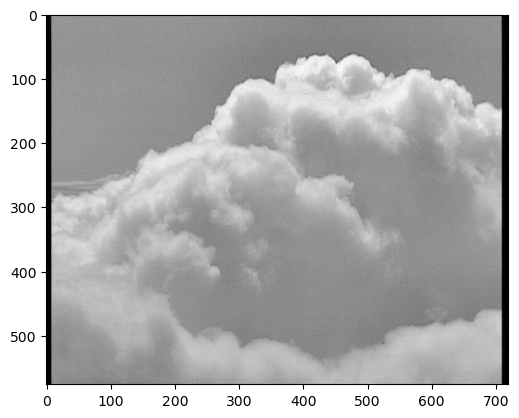

In [95]:
plt.imshow(img_grey,cmap='gray')  
 

In [96]:
img_grey = cv2.bilateralFilter(img, 9, 75, 75)
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (5, 5), 0)
  

In [97]:
img_grey = cv2.bilateralFilter(img, 9, 75, 75)
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (5, 5), 0)
edges = cv2.Canny(cv_grey, 0, 200)
edges[NOTSKY::,:]=0
edges[:,0:20]=0
edges[:,-15::]=0

# Find contours and sort by area
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

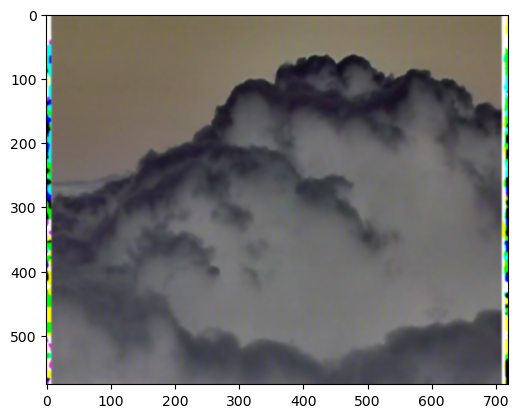

In [98]:

plt.imshow(cv_grey)

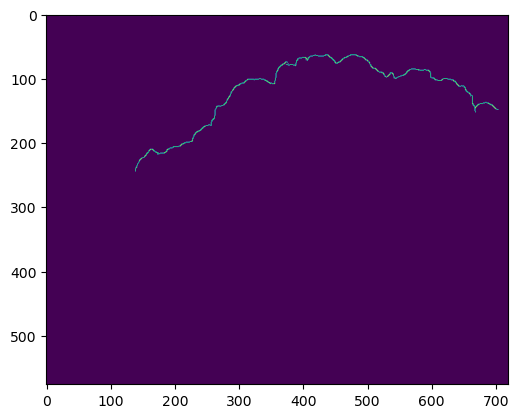

In [99]:

plt.imshow(edges)

In [100]:
# Draw the contours on the original image
thickness = 8  # Adjust this value to control the thickness of the drawn contours
edge_image = cv2.imread(file_name).copy()
cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)

array([[[4, 5, 0],
        [6, 7, 2],
        [0, 2, 0],
        ...,
        [0, 5, 3],
        [0, 5, 5],
        [0, 5, 5]],

       [[5, 6, 1],
        [4, 5, 0],
        [0, 4, 0],
        ...,
        [0, 5, 3],
        [0, 5, 5],
        [0, 5, 5]],

       [[0, 4, 0],
        [0, 6, 1],
        [0, 7, 1],
        ...,
        [0, 6, 3],
        [0, 5, 5],
        [0, 4, 4]],

       ...,

       [[4, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 0, 1],
        [5, 0, 1],
        [5, 0, 1],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 0, 1],
        [5, 0, 1],
        [5, 0, 1],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [101]:
cv2.imwrite('cloud_edge.png', edge_image)

True

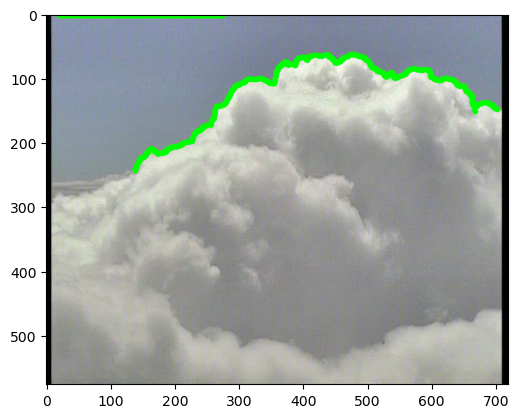

In [102]:
cloud_edge=Image.open('cloud_edge.png')
plt.imshow(cloud_edge)

In [103]:
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
bounding_box_image = cv2.imread(file_name).copy()
max =0 
for contour in sorted_contours:
    (x, y, w, h) = cv2.boundingRect(contour)
    rectanglea = w*h
    print(rectanglea,max)
    if rectanglea >= max:
        x_max = x
        y_max = y
        w_max = w
        h_max = h
        max=rectanglea

29790 0
40698 29790
774 40698


In [104]:
cv2.rectangle(bounding_box_image, (x_max, y_max), (x_max + w_max, y_max + h_max), (0, 255, 0), thickness)

array([[[4, 5, 0],
        [6, 7, 2],
        [0, 2, 0],
        ...,
        [0, 5, 3],
        [0, 5, 5],
        [0, 5, 5]],

       [[5, 6, 1],
        [4, 5, 0],
        [0, 4, 0],
        ...,
        [0, 5, 3],
        [0, 5, 5],
        [0, 5, 5]],

       [[0, 4, 0],
        [0, 6, 1],
        [0, 7, 1],
        ...,
        [0, 6, 3],
        [0, 5, 5],
        [0, 4, 4]],

       ...,

       [[4, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 0, 1],
        [5, 0, 1],
        [5, 0, 1],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 0, 1],
        [5, 0, 1],
        [5, 0, 1],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

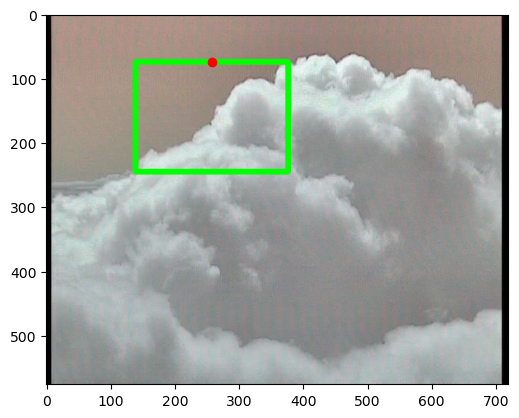

In [105]:
plt.imshow(bounding_box_image)
x_mw = (x_max + w_max/2)
plt.plot(x_mw, y_max, 'ro')


In [106]:
pixel_height = 576- y_max

# find cloud height

In [107]:
focal_length_mm = 50         # Focal Length in mm
sensor_height_mm = 24        # Sensor height in mm
sensor_width_mm = 35.9       # Sensor width in mm
focal_length_mm = 50.0       # Focal length in mm
FOV = 0         # Field of View (to be calculated later)

In [108]:
# Calculating FOV angles in degrees

# Calculate FOV angles in radians
fov_horizontal_rad = 2 * math.atan(sensor_width_mm / (2 * focal_length_mm))
fov_vertical_rad = 2 * math.atan(sensor_height_mm / (2 * focal_length_mm))

# Convert FOV angles to degrees
fov_horizontal_deg = math.degrees(fov_horizontal_rad)
fov_vertical_deg = math.degrees(fov_vertical_rad)
FOV = fov_vertical_deg

# Displaying FOV angles
print("FOV Horizontal Angle:", fov_horizontal_deg, "degrees")
print("FOV Vertical Angle:", fov_vertical_deg, "degrees")

FOV Horizontal Angle: 39.496276026438636 degrees
FOV Vertical Angle: 26.991466561591622 degrees


In [109]:
# Function to find height of an object given its pixel position on the sensor


def find_height(P, Distance, focal_length_mm, sensor_height_mm):
    """
    Calculate the height of an object given its pixel position on the sensor.

    Parameters:
    - P: Pixel position of the object on the sensor
    - Distance: Distance to the object in millimeters
    - focal_length_mm: Focal length of the camera lens in millimeters
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Height of the object in kilometers (rounded to 2 decimal places)
    """
    OHS = find_OHS(P, sensor_height_mm)
    H = (Distance * 10**3 * OHS) / focal_length_mm
    return round(H / 10**3, 2)

# Object height on sensor =  (Sensor height (mm) × Object height (pixels))
#                                      / Sensor height (pixels)
# Sensor height (px) = Sensor height (mm) / distance between pixels
# sensor_height_pixels = 24*10**-3 / 5.73*10**-6
# sensor_height_pixels = 4188

# Function to calculate Object Height on Sensor


def find_OHS(P, sensor_height_mm):
    """
    Calculate the Object Height on Sensor.

    Parameters:
    - P: Pixel position of the object on the sensor
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Object Height on Sensor
    """
    sensor_height_pixels = 4188
    OHS = sensor_height_mm * P / sensor_height_pixels
    return OHS


def pitch_correct(P, FieldOfView, h):
    """
    Correct the pitch of the camera based on angles and height.

    Parameters:
    - P: pitch in degrees
    - FieldOfView: Field of View of the camera in degrees
    - h: Height on the inclined plane

    Returns:
    - True height after pitch correction
    """
    # See diagram for agles a, b and c
    a = 90 - P - FieldOfView/2
    b = 180 - 90 - FieldOfView/2
    # image plane incline from vertical
    c = 180 - a - b
    # x is true height, h is height on incled place
    x = h * math.cos(math.radians(c))
    return x

In [124]:
CTH_raw= find_height(pixel_height, D, focal_length_mm, sensor_height_mm)
CTH_rel_to_plane = pitch_correct(-aircraft_position['pitch'], FOV, CTH_raw)


In [111]:
cloud_top_height = CTH_rel_to_plane + aircraft_position['alt']

In [125]:
CTH_rel_to_plane 

115.80930427069232

In [112]:
print('the estimated cloud top height is: ', cloud_top_height)

the estimated cloud top height is:  7318.464197951806


In [113]:
print('the pass height was: ', pass_info[2])

the pass height was:  5208.7275


In [114]:
aircraft_position

times          2022-07-27 16:41:33
lat                      33.987732
lon                    -107.309433
pitch                     5.410146
alt                    7213.313477
roll_angles              -1.952127
Name: 11116, dtype: object

In [127]:
cloud_passes.iloc[211]

Unnamed: 0                            211
flight_id                            c305
start_index                         11090
start_datetime        2022-07-27 16:41:07
end_index                           11103
end_datetime          2022-07-27 16:41:20
npasses                               1.0
passes_start_index                [11090]
passes_end_index                  [11103]
start_lon                      -107.26919
start_lat                       33.967453
end_lon                         -107.2893
end_lat                          33.97775
alt_pre                           7256.04
pressalt_pre                    6812.2935
press_pre                       421.57578
alt                             5208.7275
pressalt                         4895.088
press                            562.2473
alt_post                        7221.3667
pressalt_post                    6782.897
press_post                      423.35587
nondT_pre                        258.7847
deicedT_pre                     25